# Analiza podatkov

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.max_rows = 20
name = "Feinberg"
goals = pd.read_csv(f'{name}.csv', index_col='id')
goals['draft_ratio'] = round(100*goals['drafted'] / goals['choice'])
goals['win_ratio'] = round(100*goals['completed'] / (goals['completed'] + goals['lost']))


**1) Cilji, ki jih igralec najpogosteje zmaga**

In [142]:

goals[goals['completed'] + goals['lost'] >= 3].sort_values(by='win_ratio', ascending=False)[['name','win_ratio']].head(20).rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)'})


,Ime,Zmagan (%)
id,,
21,Brew a Potion of Swiftness,100.0
49,Die to TNT Minecart,100.0
31,Craft 100 Unique Items,100.0
92,Get on Nether Roof,100.0
72,Enter The End,100.0
73,Explode End Crystal,100.0
81,Find a Stronghold,100.0
51,Drink Honey Bottle,100.0
44,Die to Falling Stalactite,100.0


In [71]:
goals[goals['completed'] + goals['lost'] >= 3].sort_values(by='win_ratio', ascending=True)[['name','win_ratio']].head(20).rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)'})

,Ime,Zmagan (%)
id,,
295,Use Brush on Suspicious Sand/Gravel,0.0
69,Empty Hunger Bar,9.0
136,Mine Crafter,13.0
234,Obtain Dried Kelp Block,17.0
143,Obtain Mob Kabob Advancement,24.0
114,Kill Yellow Sheep,25.0
137,Mine Diamond Ore,25.0
27,Construct a Copper Golem,25.0
293,Use Anvil,25.0


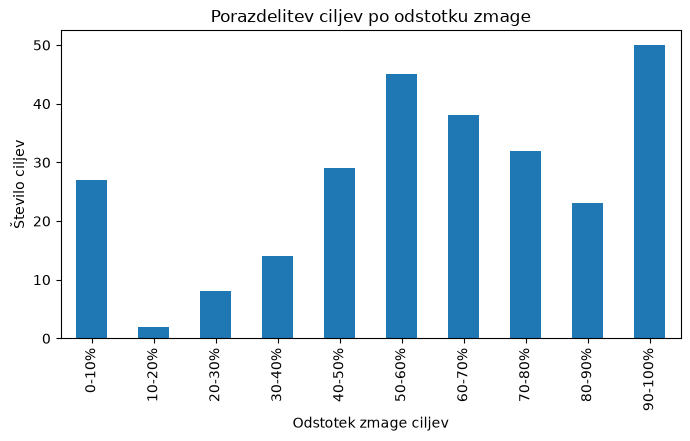

In [151]:
tenths = [0]*10

    
for _, row in goals.iterrows():
    item = row['win_ratio']
    if item == 100:
        tenths[9]+=1
    elif not pd.isna(item):
        tenths[int(item // 10)] += 1



oznake = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%']

desetine_graf = pd.Series(tenths, index=oznake)

desetine_graf.plot(
    title='Porazdelitev ciljev po odstotku zmage',
    kind='bar',
    figsize=(8, 4),
    xlabel='Odstotek zmage ciljev',
    ylabel='Število ciljev',
)


plt.show()

**2) Najpogosteje in najredkeje izbrani cilji**


In [76]:



goals[goals['choice'] >= 3].sort_values(by='draft_ratio', ascending=False)[['name','draft_ratio','win_ratio']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)'})




,Ime,Izbran (%),Zmagan (%)
id,,,
21,Brew a Potion of Swiftness,100.0,100.0
31,Craft 100 Unique Items,100.0,100.0
59,Eat 25 Unique Food,100.0,100.0
159,Obtain 20 Advancements,100.0,86.0
151,Obtain 3 types of Horse Armor,100.0,75.0
336,Wear Light Gray Leather Chestplate,100.0,33.0
238,Obtain every type of Minecart,100.0,100.0
261,Obtain Smooth Quartz Stairs,92.0,87.0
95,Have your Shield disabled,91.0,54.0


In [74]:



goals[goals['choice'] >= 3].sort_values(by='draft_ratio', ascending=True)[['name','draft_ratio','win_ratio']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)'})




,Ime,Izbran (%),Zmagan (%)
id,,,
6,Breed Camels,0.0,NaN
9,Breed Foxes,0.0,NaN
14,Breed Rabbits,0.0,100.0
34,Die by Drowning,0.0,33.0
65,Eat every type of Soup,0.0,NaN
44,Die to Falling Stalactite,0.0,100.0
41,Die to Berry Bush,0.0,100.0
103,Kill all Raid Mobs,0.0,NaN
153,Obtain 4 Unique Saplings,0.0,25.0


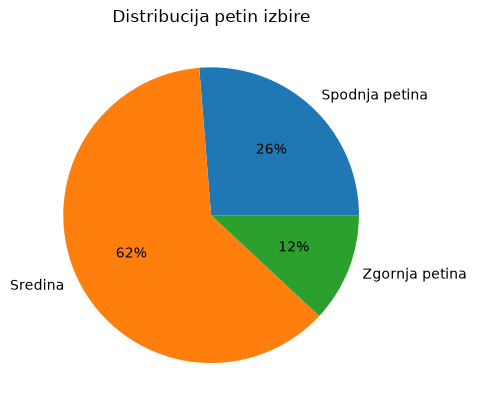

In [ ]:

count_low = (goals['draft_ratio'] <= 20).sum()
count_high = (goals['draft_ratio'] >= 80).sum()
count_mid = ((goals['draft_ratio']>20) & (goals['draft_ratio']<80)).sum()
count_sum=count_low+count_high+count_mid


data = pd.DataFrame({
    'Name': ['Spodnja petina'] + ['Sredina'] + ['Zgornja petina'] ,
    'Percentage': [
        count_low,
        count_mid,
        count_high,
    ],
})


data.groupby('Name')['Percentage'].sum().plot(
    kind='pie',
    autopct='%1.0f%%',
    ylabel='',
    legend=False,
    title='Distribucija petin izbire',
)

plt.show()

**3) Učinkovitost izbire**

In [78]:
goals['draft_efficiency'] = (goals['draft_ratio'] + goals['win_ratio'])/2
goals[goals['draft_efficiency'].notnull() & (goals['appeared']>= 3)].sort_values(by=['draft_efficiency'], ascending=[False])
goals[goals['appeared']>= 3].sort_values(by='draft_efficiency', ascending=False)[['name','draft_ratio','win_ratio', 'draft_efficiency']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)', 'draft_efficiency': 'Učinkovitost izbire (%)'})


,Ime,Izbran (%),Zmagan (%),Učinkovitost izbire (%)
id,,,,
21,Brew a Potion of Swiftness,100.0,100.0,100.0
31,Craft 100 Unique Items,100.0,100.0,100.0
59,Eat 25 Unique Food,100.0,100.0,100.0
238,Obtain every type of Minecart,100.0,100.0,100.0
307,Wear Black Leather Boots,100.0,100.0,100.0
160,Obtain 30 Advancements,100.0,100.0,100.0
159,Obtain 20 Advancements,100.0,86.0,93.0
261,Obtain Smooth Quartz Stairs,92.0,87.0,89.5
80,Fill Inventory with unique items,88.0,89.0,88.5


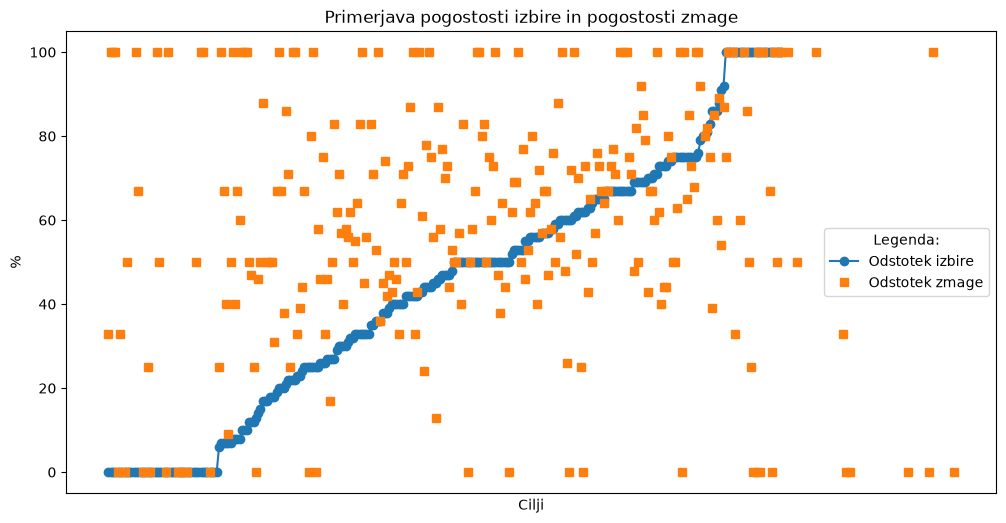

In [115]:

draft_sorted = goals.sort_values(by='draft_ratio').reset_index(drop=True)
x_axis = draft_sorted.index
plt.figure(figsize=(12, 6))

plt.plot(
    x_axis,
    draft_sorted['draft_ratio'],
    marker='o',
    linestyle='-',
    color='tab:blue',
    label='Odstotek izbire',
)

plt.plot(
    x_axis,
    draft_sorted['win_ratio'],
    marker='s',
    linestyle='None',
    color='tab:orange',
    label='Odstotek zmage',
)
plt.xticks([])
plt.title('Primerjava pogostosti izbire in pogostosti zmage')
plt.xlabel('Cilji')
plt.ylabel('%')
plt.legend(title='Legenda:')
plt.show()

**4) Najredkeje in najpogosteje opravljeni cilji**

In [117]:
goals['completion_ratio'] = round(100*(goals['completed'] + goals['lost']) / goals['appeared'])
goals.sort_values(by='completion_ratio', ascending=False)[['name','win_ratio','completion_ratio']].head(20).rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)', 'completion_ratio': 'Opravljen (%)'})


,Ime,Zmagan (%),Opravljen (%)
id,,,
378,Write a Book,70.0,100.0
1,Break any Tool,58.0,100.0
291,Trade with a Villager,77.0,100.0
360,Wear Red Leather Chestplate,50.0,100.0
300,Use Grindstone,39.0,100.0
297,Use Cauldron to wash something,76.0,100.0
292,Tune a Note Block,56.0,100.0
33,Decorate Shield with Banner,58.0,100.0
34,Die by Drowning,33.0,100.0


In [118]:
goals.sort_values(by='completion_ratio', ascending=True)[['name','draft_ratio','completion_ratio']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'completion_ratio': 'Opravljen (%)'})

,Ime,Izbran (%),Opravljen (%)
id,,,
306,Wear a Chain Armor Piece,80.0,0.0
63,Eat Beetroot Soup,67.0,0.0
288,Tame a Parrot,0.0,0.0
287,Tame a Nautilus,0.0,0.0
99,Kill 15 Unique Hostile Mobs,50.0,0.0
117,Kill Elder Guardian,NaN,0.0
264,Obtain Suspicious Sand/Gravel,17.0,0.0
271,Put Wolf Armor on Wolf,0.0,0.0
214,Obtain Magenta Glazed Terracotta,50.0,0.0


**5) Analiza igralca Feinberg**